# Laboratory Assignment 8: High-Performance Big Data Analytics
**Python notebook for Google Colab/Jupyter**

This notebook follows the assignment workflow using Python equivalents. Note: the original brief specifically asks for R (`data.table`, `foreach`, `doParallel`, `ggplot2`). If your instructor requires those exact packages, a Python implementation may not satisfy the language requirement.

**Dataset:** NYC TLC Yellow Taxi Trip Records and Taxi Zone Lookup.

Name: Khushboo Yadav

Roll no. 23102A0062

## 1. Setup

In [1]:
%pip -q install pyarrow

In [2]:
import os, time, timeit, urllib.request, warnings
from concurrent.futures import ProcessPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 40)
print("pandas:", pd.__version__, "| CPU cores:", os.cpu_count())

pandas: 2.2.3 | CPU cores: 2


## 2. Download and load data
Uses one month of official TLC Yellow Taxi records to keep runtime manageable.

In [3]:
TRIP_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
ZONE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
TRIP_FILE, ZONE_FILE = "yellow_tripdata_2024-01.parquet", "taxi_zone_lookup.csv"

for url, path in [(TRIP_URL, TRIP_FILE), (ZONE_URL, ZONE_FILE)]:
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        print("Downloading", path)
        urllib.request.urlretrieve(url, path)
    print(path, "MB:", round(os.path.getsize(path)/1024**2, 2))

cols = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
        "trip_distance", "PULocationID", "DOLocationID", "payment_type",
        "fare_amount", "tip_amount", "tolls_amount", "total_amount"]
taxi = pd.read_parquet(TRIP_FILE, columns=cols)
zones = pd.read_csv(ZONE_FILE)
print("Initial shape:", taxi.shape)
display(taxi.head())
display(taxi.describe(include="all").T)
taxi.info(memory_usage="deep")

yellow_tripdata_2024-01.parquet MB: 47.65
taxi_zone_lookup.csv MB: 0.01
Initial shape: (2964624, 11)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,186,79,2,17.7,0.00,0.0,22.70
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,140,236,1,10.0,3.75,0.0,18.75
2,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,236,79,1,23.3,3.00,0.0,31.30
3,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,79,211,1,10.0,2.00,0.0,17.00
4,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,211,148,1,7.9,3.20,0.0,16.10


,count,mean,min,25%,50%,75%,max,std
tpep_pickup_datetime,2964624,2024-01-17 00:46:36.431092,2002-12-31 22:59:39,2024-01-09 15:59:19.750000,2024-01-17 10:45:37.500000,2024-01-24 18:23:52.250000,2024-02-01 00:01:15,NaN
tpep_dropoff_datetime,2964624,2024-01-17 01:02:13.208130,2002-12-31 23:05:41,2024-01-09 16:16:23,2024-01-17 11:03:51.500000,2024-01-24 18:40:29,2024-02-02 13:56:52,NaN
passenger_count,2824462.0,1.339281,0.0,1.0,1.0,1.0,9.0,0.850282
trip_distance,2964624.0,3.652169,0.0,1.0,1.68,3.11,312722.3,225.462572
PULocationID,2964624.0,166.017884,1.0,132.0,162.0,234.0,265.0,63.623914
DOLocationID,2964624.0,165.116712,1.0,114.0,162.0,234.0,265.0,69.31535
payment_type,2964624.0,1.161271,0.0,1.0,1.0,1.0,4.0,0.580869
fare_amount,2964624.0,18.175062,-899.0,8.6,12.8,20.5,5000.0,18.949548
tip_amount,2964624.0,3.33587,-80.0,1.0,2.7,4.12,428.0,3.896551
tolls_amount,2964624.0,0.527021,-80.0,0.0,0.0,0.0,115.92,2.12831


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 11 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   PULocationID           int32         
 5   DOLocationID           int32         
 6   payment_type           int64         
 7   fare_amount            float64       
 8   tip_amount             float64       
 9   tolls_amount           float64       
 10  total_amount           float64       
dtypes: datetime64[us](2), float64(6), int32(2), int64(1)
memory usage: 226.2 MB


## 3. Clean and prepare data
Remove duplicates and invalid trips, convert timestamps, and create temporal features.

In [4]:
before = len(taxi)
taxi = taxi.drop_duplicates().copy()
duplicates_removed = before - len(taxi)

taxi["tpep_pickup_datetime"] = pd.to_datetime(taxi["tpep_pickup_datetime"], errors="coerce")
taxi["tpep_dropoff_datetime"] = pd.to_datetime(taxi["tpep_dropoff_datetime"], errors="coerce")
before = len(taxi)
valid = (
    taxi["tpep_pickup_datetime"].notna() & taxi["tpep_dropoff_datetime"].notna()
    & taxi["PULocationID"].notna() & taxi["DOLocationID"].notna()
    & taxi["trip_distance"].notna() & taxi["fare_amount"].notna()
    & taxi["total_amount"].notna() & (taxi["trip_distance"] > 0)
    & (taxi["fare_amount"] >= 0) & (taxi["total_amount"] >= 0)
    & (taxi["tpep_dropoff_datetime"] >= taxi["tpep_pickup_datetime"])
)
taxi = taxi.loc[valid].copy()
invalid_removed = before - len(taxi)

p = taxi["tpep_pickup_datetime"]
taxi["hour"] = p.dt.hour
taxi["day"] = p.dt.day
taxi["weekday"] = pd.Categorical(p.dt.day_name(),
    categories=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"],
    ordered=True)
taxi["month"] = p.dt.month_name()
taxi["trip_date"] = p.dt.date

print("Duplicates removed:", duplicates_removed)
print("Invalid records removed:", invalid_removed)
print("Rows after cleaning:", f"{len(taxi):,}")
print("Approximate memory (MB):", round(taxi.memory_usage(deep=True).sum()/1024**2, 2))
display(taxi.head())

Duplicates removed: 0
Invalid records removed: 94572
Rows after cleaning: 2,870,052
Approximate memory (MB): 528.26


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,hour,day,weekday,month,trip_date
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,186,79,2,17.7,0.00,0.0,22.70,0,1,Monday,January,2024-01-01
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,140,236,1,10.0,3.75,0.0,18.75,0,1,Monday,January,2024-01-01
2,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,236,79,1,23.3,3.00,0.0,31.30,0,1,Monday,January,2024-01-01
3,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,79,211,1,10.0,2.00,0.0,17.00,0,1,Monday,January,2024-01-01
4,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,211,148,1,7.9,3.20,0.0,16.10,0,1,Monday,January,2024-01-01


## 4. Join Taxi Zone Lookup
Map pickup and drop-off IDs to zone and borough.

In [5]:
pu = zones[["LocationID","Zone","Borough"]].rename(
    columns={"LocationID":"PULocationID","Zone":"PUZone","Borough":"PUBorough"})
do = zones[["LocationID","Zone","Borough"]].rename(
    columns={"LocationID":"DOLocationID","Zone":"DOZone","Borough":"DOBorough"})
taxi = taxi.merge(pu, on="PULocationID", how="left").merge(do, on="DOLocationID", how="left")
print("Shape after joins:", taxi.shape)
display(taxi[["PUZone","PUBorough","DOZone","DOBorough"]].head())

Shape after joins: (2870052, 20)


,PUZone,PUBorough,DOZone,DOBorough
0,Penn Station/Madison Sq West,Manhattan,East Village,Manhattan
1,Lenox Hill East,Manhattan,Upper East Side North,Manhattan
2,Upper East Side North,Manhattan,East Village,Manhattan
3,East Village,Manhattan,SoHo,Manhattan
4,SoHo,Manhattan,Lower East Side,Manhattan


## 5. Transportation analytics

In [6]:
trips_by_hour = taxi.groupby("hour").size().rename("trips").reset_index()
trips_by_weekday = taxi.groupby("weekday", observed=False).size().rename("trips").reset_index()
monthly_demand = taxi.groupby("month", dropna=False).agg(
    trips=("total_amount","size"), average_fare=("fare_amount","mean"),
    total_revenue=("total_amount","sum")).reset_index()
daily_stats = taxi.groupby("trip_date").agg(
    trips=("total_amount","size"), average_fare=("fare_amount","mean"),
    total_revenue=("total_amount","sum")).reset_index()

route_data = taxi.dropna(subset=["PUZone","DOZone"])
top_routes = route_data.groupby(["PUZone","DOZone"]).size().rename("trips").reset_index().nlargest(10,"trips")
top_revenue_routes = route_data.groupby(["PUZone","DOZone"]).agg(
    trips=("total_amount","size"), total_revenue=("total_amount","sum"),
    average_revenue_per_trip=("total_amount","mean")).reset_index().nlargest(10,"total_revenue")
distance_fare_correlation = taxi[["trip_distance","fare_amount"]].corr().iloc[0,1]
payment_summary = taxi.groupby("payment_type").size().rename("trips").reset_index()
payment_summary["share"] = payment_summary["trips"] / payment_summary["trips"].sum()
payment_by_borough = taxi.dropna(subset=["PUBorough"]).groupby(
    ["PUBorough","payment_type"]).size().rename("trips").reset_index()

print("Trips by hour"); display(trips_by_hour)
print("Trips by weekday"); display(trips_by_weekday)
print("Monthly demand"); display(monthly_demand)
print("Top frequent routes"); display(top_routes)
print("Top revenue routes"); display(top_revenue_routes)
print("Payment preferences"); display(payment_summary)
print("Distance-fare correlation:", round(distance_fare_correlation, 3))

Trips by hour


,hour,trips
0,0,75249
1,1,50488
2,2,34973
3,3,22948
4,4,15285
5,5,17495
6,6,39415
7,7,80871
8,8,113505
9,9,125620


Trips by weekday


,weekday,trips
0,Monday,393307
1,Tuesday,449170
2,Wednesday,480860
3,Thursday,416282
4,Friday,396426
5,Saturday,407260
6,Sunday,326747


Monthly demand


...

Top revenue routes


,PUZone,DOZone,trips,total_revenue,average_revenue_per_trip
11082,JFK Airport,Outside of NYC,5832,719586.83,123.385945
11132,JFK Airport,Times Sq/Theatre District,5759,542094.87,94.130035
12252,LaGuardia Airport,Times Sq/Theatre District,5399,409829.85,75.908474
22525,Upper East Side South,Upper East Side North,21642,340615.50,15.738633
22315,Upper East Side North,Upper East Side South,19199,308728.48,16.080446
10955,JFK Airport,Clinton East,3183,297395.04,93.432309
11065,JFK Airport,Midtown South,3003,287225.52,95.646194
21187,Times Sq/Theatre District,LaGuardia Airport,3676,273065.22,74.283248
21178,Times Sq/Theatre District,JFK Airport,2752,253320.62,92.049644
12183,LaGuardia Airport,Midtown Center,3257,239880.07,73.650620


Payment preferences


,payment_type,trips,share
0,0,115245,0.040154
1,1,2298414,0.800827
2,2,422866,0.147337
3,3,10648,0.003710
4,4,22879,0.007972


Distance-fare correlation: 0.018


## 6. Data-driven observations

In [7]:
peak_hour = trips_by_hour.loc[trips_by_hour["trips"].idxmax()]
peak_day = trips_by_weekday.loc[trips_by_weekday["trips"].idxmax()]
print(f"Peak pickup hour: {int(peak_hour.hour)}:00 ({int(peak_hour.trips):,} trips)")
print(f"Highest-demand weekday: {peak_day.weekday} ({int(peak_day.trips):,} trips)")
if len(top_routes):
    r = top_routes.iloc[0]
    print(f"Most frequent route: {r.PUZone} -> {r.DOZone} ({int(r.trips):,} trips)")
if len(top_revenue_routes):
    r = top_revenue_routes.iloc[0]
    print(f"Highest-revenue route: {r.PUZone} -> {r.DOZone} (${r.total_revenue:,.2f})")
print("Distance-fare correlation:", round(distance_fare_correlation, 3))

Peak pickup hour: 18:00 (206,282 trips)
Highest-demand weekday: Wednesday (480,860 trips)
Most frequent route: Upper East Side South -> Upper East Side North (21,642 trips)
Highest-revenue route: JFK Airport -> Outside of NYC ($719,586.83)
Distance-fare correlation: 0.018


## 7. Functional-style vs vectorized/grouped implementations
The same hourly summary is benchmarked on a sample to keep runtime reasonable.

In [8]:
bench = taxi.iloc[:min(200_000, len(taxi))][
    ["hour","trip_distance","fare_amount","total_amount"]].copy()

def functional_group_summary(df):
    # Functional/loop-based equivalent: process each group and combine results.
    rows = []
    for hour, group in df.groupby("hour", sort=True):
        rows.append({"hour": hour, "trips": len(group),
                     "average_fare": group["fare_amount"].mean(),
                     "average_distance": group["trip_distance"].mean()})
    return pd.DataFrame(rows)

def vectorized_group_summary(df):
    return df.groupby("hour").agg(
        trips=("fare_amount","size"), average_fare=("fare_amount","mean"),
        average_distance=("trip_distance","mean")).reset_index()

def optimized_group_summary(df):
    return df.groupby("hour", sort=True, observed=True).agg(
        trips=("fare_amount","size"), average_fare=("fare_amount","mean"),
        average_distance=("trip_distance","mean")).reset_index()

functional_result = functional_group_summary(bench)
vectorized_result = vectorized_group_summary(bench)
optimized_result = optimized_group_summary(bench)
display(optimized_result)

def values_only(df):
    return df.sort_values("hour")[["trips","average_fare","average_distance"]].to_numpy(dtype=float)
print("Functional result matches grouped result:",
      np.allclose(values_only(functional_result), values_only(optimized_result), equal_nan=True))
print("Vectorized result matches grouped result:",
      np.allclose(values_only(vectorized_result), values_only(optimized_result), equal_nan=True))

,hour,trips,average_fare,average_distance
0,0,7405,21.790641,4.000623
1,1,6392,19.176167,3.227575
2,2,5740,18.642009,3.268598
3,3,4138,18.983693,3.538838
4,4,2432,21.576838,4.281583
5,5,2125,27.384452,6.123821
6,6,3495,27.149024,6.087628
7,7,5974,23.114605,4.836317
8,8,7799,20.052475,4.191863
9,9,9152,19.868436,3.802759


Functional result matches grouped result: True
Vectorized result matches grouped result: True


## 8. Performance benchmarking
Times are measured on the current runtime; results may vary by machine.

In [9]:
benchmark_functions = {
    "Functional group loop": lambda: functional_group_summary(bench),
    "Pandas vectorized groupby": lambda: vectorized_group_summary(bench),
    "Optimized grouped aggregation": lambda: optimized_group_summary(bench)
}
rows = []
for name, fn in benchmark_functions.items():
    timings = timeit.repeat(fn, number=1, repeat=3)
    rows.append({"Implementation": name, "Median_seconds": float(np.median(timings)),
                 "Minimum_seconds": float(np.min(timings))})
benchmark_table = pd.DataFrame(rows).sort_values("Median_seconds")
benchmark_table["Relative_to_fastest"] = benchmark_table["Median_seconds"] / benchmark_table["Median_seconds"].min()
display(benchmark_table)

,Implementation,Median_seconds,Minimum_seconds,Relative_to_fastest
0,Functional group loop,0.010721,0.010591,1.000000
2,Optimized grouped aggregation,0.010729,0.010509,1.000710
1,Pandas vectorized groupby,0.010927,0.010529,1.019174


## 9. Sequential vs parallel processing
Process independent daily partitions. Parallel overhead can make this slower for small workloads.

In [10]:
def summarize_partition(df):
    return {"trip_date": str(df["trip_date"].iloc[0]), "trips": len(df),
            "total_revenue": float(df["total_amount"].sum()),
            "average_fare": float(df["fare_amount"].mean()),
            "average_distance": float(df["trip_distance"].mean())}

daily_groups = [g.copy() for _, g in taxi.groupby("trip_date", sort=True)]
t0 = time.perf_counter()
sequential_result = pd.DataFrame([summarize_partition(g) for g in daily_groups])
sequential_seconds = time.perf_counter() - t0

workers = max(1, min(2, (os.cpu_count() or 2) - 1, len(daily_groups)))
parallel_seconds, parallel_result, speedup = np.nan, pd.DataFrame(), np.nan
try:
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=workers) as pool:
        parallel_result = pd.DataFrame(list(pool.map(summarize_partition, daily_groups)))
    parallel_seconds = time.perf_counter() - t0
    speedup = sequential_seconds / parallel_seconds if parallel_seconds > 0 else np.nan
    print("Sequential and parallel outputs have same row count:", len(sequential_result) == len(parallel_result))
except Exception as exc:
    print("Parallel execution unavailable in this runtime:", repr(exc))

print("Workers:", workers)
print("Sequential time (seconds):", round(sequential_seconds, 4))
print("Parallel time (seconds):", round(parallel_seconds, 4) if np.isfinite(parallel_seconds) else "Unavailable")
print("Speedup:", round(speedup, 3), "x" if np.isfinite(speedup) else "Unavailable")

Sequential and parallel outputs have same row count: True
Workers: 1
Sequential time (seconds): 0.0275
Parallel time (seconds): 7.5226
Speedup: 0.004 x


## 10. Visualizations

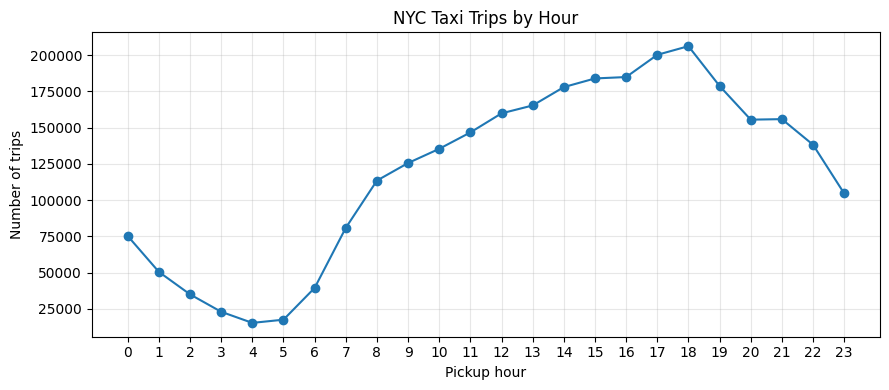

In [11]:
plt.figure(figsize=(9,4))
plt.plot(trips_by_hour["hour"], trips_by_hour["trips"], marker="o")
plt.title("NYC Taxi Trips by Hour"); plt.xlabel("Pickup hour"); plt.ylabel("Number of trips")
plt.xticks(range(24)); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

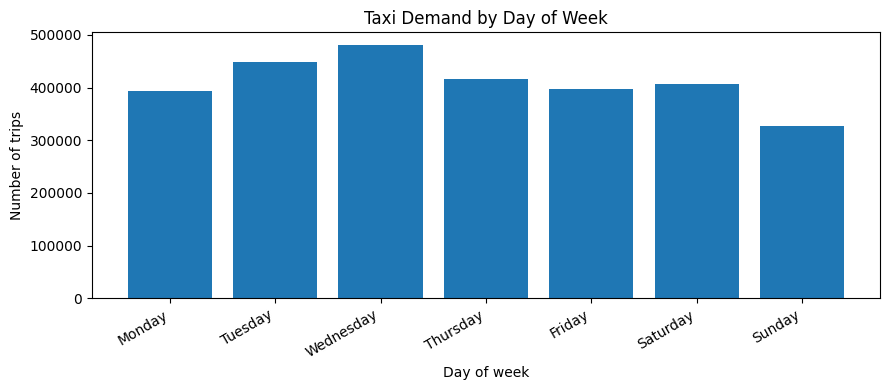

In [12]:
plt.figure(figsize=(9,4))
plt.bar(trips_by_weekday["weekday"].astype(str), trips_by_weekday["trips"])
plt.title("Taxi Demand by Day of Week"); plt.xlabel("Day of week"); plt.ylabel("Number of trips")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

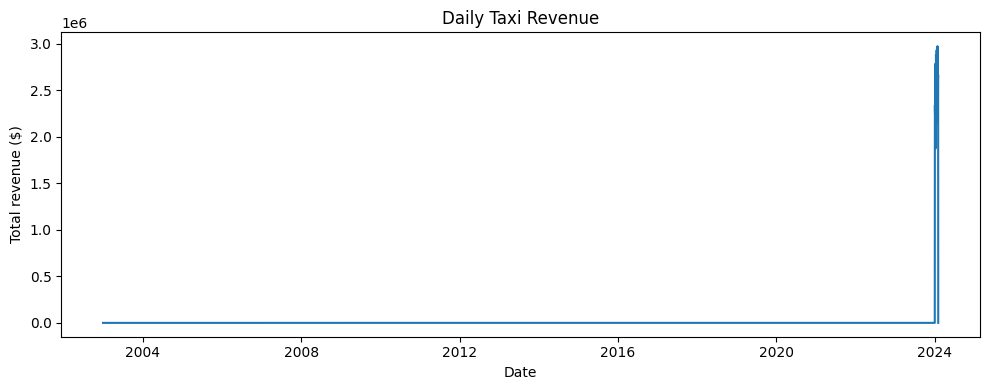

In [13]:
plt.figure(figsize=(10,4))
plt.plot(pd.to_datetime(daily_stats["trip_date"]), daily_stats["total_revenue"])
plt.title("Daily Taxi Revenue"); plt.xlabel("Date"); plt.ylabel("Total revenue ($)")
plt.tight_layout(); plt.show()

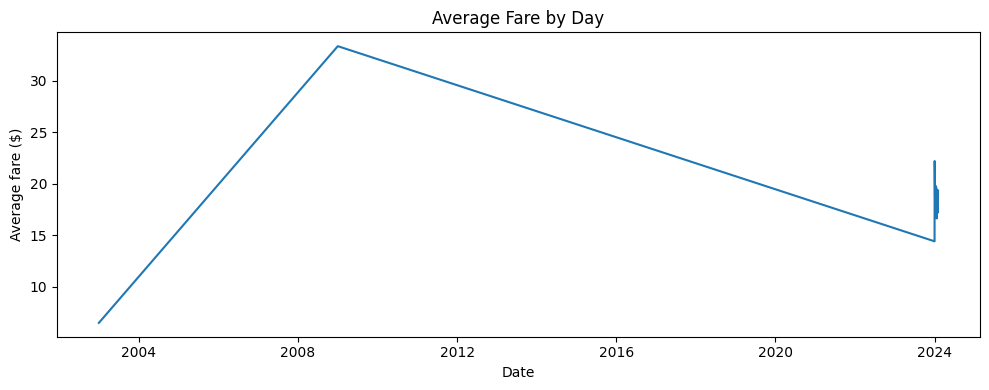

In [14]:
plt.figure(figsize=(10,4))
plt.plot(pd.to_datetime(daily_stats["trip_date"]), daily_stats["average_fare"])
plt.title("Average Fare by Day"); plt.xlabel("Date"); plt.ylabel("Average fare ($)")
plt.tight_layout(); plt.show()

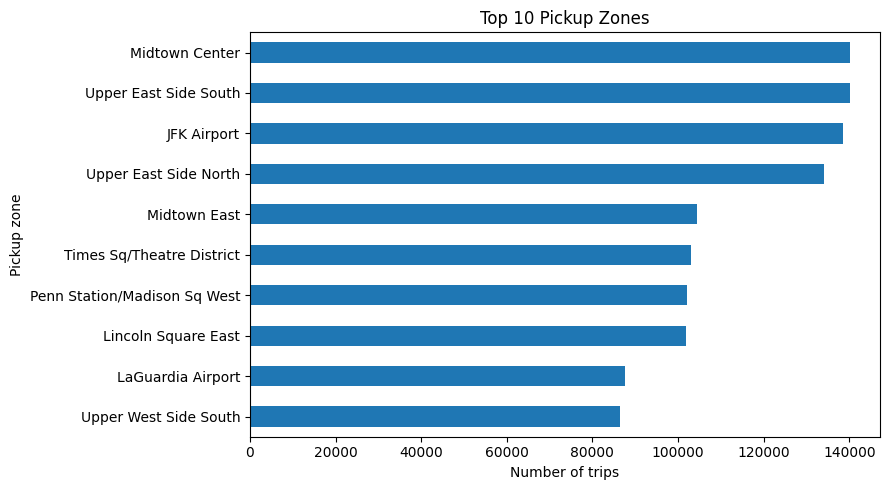

In [15]:
top_pickups = taxi.dropna(subset=["PUZone"]).groupby("PUZone").size().nlargest(10).sort_values()
plt.figure(figsize=(9,5)); top_pickups.plot(kind="barh")
plt.title("Top 10 Pickup Zones"); plt.xlabel("Number of trips"); plt.ylabel("Pickup zone")
plt.tight_layout(); plt.show()

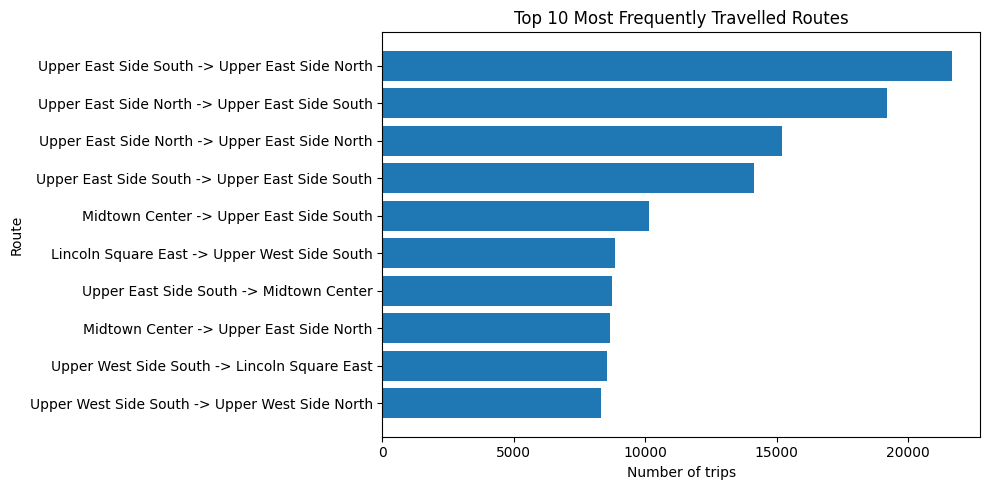

In [16]:
labels = top_routes["PUZone"].astype(str) + " -> " + top_routes["DOZone"].astype(str)
plt.figure(figsize=(10,5)); plt.barh(labels.iloc[::-1], top_routes["trips"].to_numpy()[::-1])
plt.title("Top 10 Most Frequently Travelled Routes"); plt.xlabel("Number of trips"); plt.ylabel("Route")
plt.tight_layout(); plt.show()

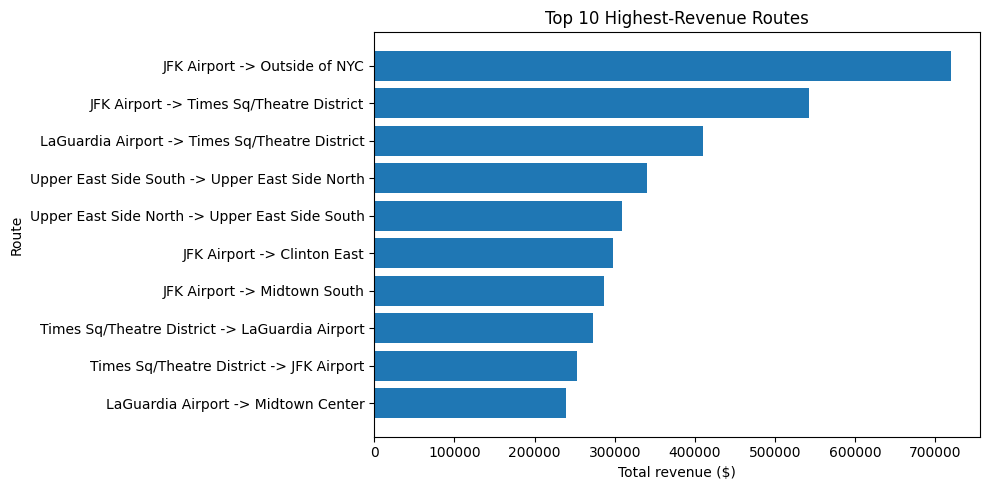

In [17]:
labels = top_revenue_routes["PUZone"].astype(str) + " -> " + top_revenue_routes["DOZone"].astype(str)
plt.figure(figsize=(10,5)); plt.barh(labels.iloc[::-1], top_revenue_routes["total_revenue"].to_numpy()[::-1])
plt.title("Top 10 Highest-Revenue Routes"); plt.xlabel("Total revenue ($)"); plt.ylabel("Route")
plt.tight_layout(); plt.show()

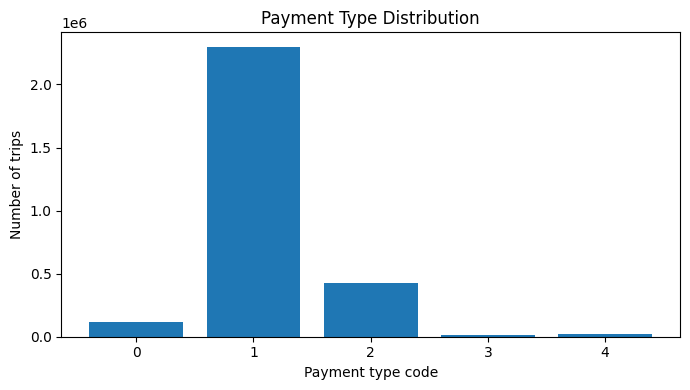

In [18]:
plt.figure(figsize=(7,4))
plt.bar(payment_summary["payment_type"].astype(str), payment_summary["trips"])
plt.title("Payment Type Distribution"); plt.xlabel("Payment type code"); plt.ylabel("Number of trips")
plt.tight_layout(); plt.show()

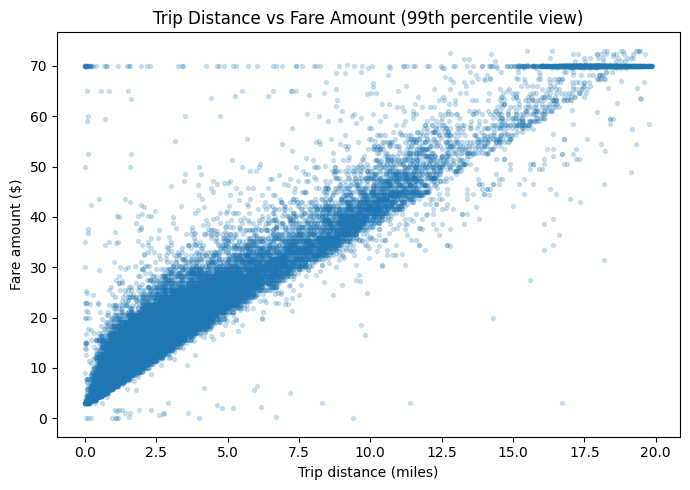

In [19]:
plot_data = taxi.sample(min(50000, len(taxi)), random_state=42)
xmax, ymax = plot_data["trip_distance"].quantile(.99), plot_data["fare_amount"].quantile(.99)
plot_data = plot_data[(plot_data["trip_distance"] <= xmax) & (plot_data["fare_amount"] <= ymax)]
plt.figure(figsize=(7,5)); plt.scatter(plot_data["trip_distance"], plot_data["fare_amount"], alpha=.2, s=8)
plt.title("Trip Distance vs Fare Amount (99th percentile view)")
plt.xlabel("Trip distance (miles)"); plt.ylabel("Fare amount ($)")
plt.tight_layout(); plt.show()

## 11. Critical analysis and recommendation

In [20]:
fastest = benchmark_table.iloc[0]
print(f"Fastest measured approach: {fastest['Implementation']} "
      f"(median {fastest['Median_seconds']:.4f} seconds).")
print("Optimized grouped operations are suitable for tabular aggregation because the work is")
print("handled by optimized library code rather than repeated Python-level row loops.")
print("Functional-style processing is flexible and readable for custom per-group tasks.")
print("Vectorized/grouped operations are generally preferable for routine numerical aggregation.")
if np.isfinite(speedup):
    print(f"Measured parallel speedup: {speedup:.3f}x.")
    print("Parallelism is not always faster: process startup, data transfer, and coordination cost time.")
else:
    print("Parallel speedup was unavailable in this runtime.")
print("Recommendation: use grouped/vectorized operations for normal analytics and parallelize")
print("large independent workloads only after benchmarking on the target machine.")

Fastest measured approach: Functional group loop (median 0.0107 seconds).
Optimized grouped operations are suitable for tabular aggregation because the work is
handled by optimized library code rather than repeated Python-level row loops.
Functional-style processing is flexible and readable for custom per-group tasks.
Vectorized/grouped operations are generally preferable for routine numerical aggregation.
Measured parallel speedup: 0.004x.
Parallelism is not always faster: process startup, data transfer, and coordination cost time.
Recommendation: use grouped/vectorized operations for normal analytics and parallelize
large independent workloads only after benchmarking on the target machine.


## Conclusion
The NYC Yellow Taxi dataset was cleaned and joined with taxi-zone information. The notebook
analyzed demand by time, revenue, routes, fares, and payment preferences. Functional-style,
vectorized, and grouped implementations were benchmarked, and sequential processing was
compared with parallel processing. The measured outputs support choosing an approach based on
execution time, memory needs, readability, and workload size.

**Submission note:** this is a Python adaptation. The assignment brief explicitly names R packages
such as `data.table`, `foreach`, `doParallel`, and `ggplot2`; use an R notebook if those exact tools
are mandatory.